In [ ]:
# ==========================================================
# Deep Learning Basics - Advanced ANN Assignment

# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

In [ ]:
# ==========================================================
# Q1
# Generate dataset with realistic imbalance (80% No Purchase)
# ==========================================================

n = 800

Age = np.random.randint(18, 61, n)

Experience = np.random.randint(0, 31, n)

Salary = (
    25000
    + Age * 1200
    + Experience * 2500
    + np.random.normal(0, 10000, n)
)

Salary = Salary.astype(int)

Purchased = np.zeros(n)

purchase_indices = np.random.choice(
    n,
    size=int(0.20*n),
    replace=False
)

Purchased[purchase_indices] = 1

df = pd.DataFrame({
    "Age":Age,
    "Salary":Salary,
    "Experience":Experience,
    "Purchased":Purchased.astype(int)
})

print(df.head())

print("\nClass Distribution")

print(df["Purchased"].value_counts())

print("\nPercentage")

print(df["Purchased"].value_counts(normalize=True)*100)

   Age  Salary  Experience  Purchased
0   56  149459          28          0
1   46  141840          19          0
2   32   89842          14          1
3   60  159418          14          0
4   25  130796          30          0

Class Distribution
Purchased
0    640
1    160
Name: count, dtype: int64

Percentage
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# Q2
# Feature Engineering
# ==========================================================

df["Salary_per_Experience"] = df["Salary"]/(df["Experience"]+1)

df["Age_Bucket"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,60],
    labels=["18-25","26-35","36-45","46+"],
    include_lowest=True
)

df["Age_Salary_Interaction"] = df["Age"]*df["Salary"]

print(df.head())

   Age  Salary  Experience  Purchased  Salary_per_Experience Age_Bucket  \
0   56  149459          28          0            5153.758621        46+   
1   46  141840          19          0            7092.000000        46+   
2   32   89842          14          1            5989.466667      26-35   
3   60  159418          14          0           10627.866667        46+   
4   25  130796          30          0            4219.225806      18-25   

   Age_Salary_Interaction  
0                 8369704  
1                 6524640  
2                 2874944  
3                 9565080  
4                 3269900  


In [ ]:
#ANN FUNCTION Q2

def build_ann(input_dim):

    model = Sequential()

    model.add(Dense(16,
                    activation="relu",
                    input_shape=(input_dim,)))

    model.add(Dense(8,
                    activation="relu"))

    model.add(Dense(1,
                    activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# ==========================================================
# Q3
# One Hot Encoding
# ==========================================================

X = df.drop("Purchased",axis=1)
y = df["Purchased"]

categorical = ["Age_Bucket"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(drop="first"),
            categorical
        )
    ],
    remainder="passthrough"
)

X_onehot = preprocessor.fit_transform(X)

sc = StandardScaler()

X_onehot = sc.fit_transform(X_onehot)

X_train,X_test,y_train,y_test = train_test_split(
    X_onehot,
    y,
    test_size=0.2,
    random_state=42
)

model = build_ann(X_train.shape[1])

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

pred = (model.predict(X_test)>0.5).astype(int)

acc_onehot = accuracy_score(y_test,pred)

print("One Hot Accuracy:",acc_onehot)

print("Input Features:",X_onehot.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
One Hot Accuracy: 0.75625
Input Features: 8


In [ ]:
# ==========================================================
# Label Encoding
# ==========================================================

df_label = df.copy()

encoder = LabelEncoder()

df_label["Age_Bucket"] = encoder.fit_transform(df_label["Age_Bucket"])

X = df_label.drop("Purchased",axis=1)

y = df_label["Purchased"]

sc = StandardScaler()

X = sc.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = build_ann(X_train.shape[1])

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

pred = (model.predict(X_test)>0.5).astype(int)

acc_label = accuracy_score(y_test,pred)

print("Label Encoding Accuracy:",acc_label)

print("Input Features:",X.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Label Encoding Accuracy: 0.75625
Input Features: 6


In [ ]:
#Q3 COMPARISON

print("========== Comparison ==========")

print("One Hot Accuracy :",acc_onehot)

print("Label Accuracy   :",acc_label)



========== Comparison ==========
One Hot Accuracy : 0.75625
Label Accuracy   : 0.75625


In [ ]:
# ==========================================================
# Q4
# Outlier Detection
# ==========================================================

Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

outliers = df[
    (df["Salary"]<lower) |
    (df["Salary"]>upper)
]

print("Total Outliers:",len(outliers))

Total Outliers: 0


In [ ]:
#Q4 ANN WITH OUTLIERS
temp = df_label.copy()

X = temp.drop("Purchased",axis=1)

y = temp["Purchased"]

sc = StandardScaler()

X = sc.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

model = build_ann(X_train.shape[1])

model.fit(X_train,y_train,epochs=20,verbose=0)

pred = (model.predict(X_test)>0.5).astype(int)

acc_with = accuracy_score(y_test,pred)

print("Accuracy With Outliers:",acc_with)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Accuracy With Outliers: 0.75625


In [ ]:
#Q4 ANN WITHOUT OUTLIERS
clean_df = temp[
    (temp["Salary"]>=lower) &
    (temp["Salary"]<=upper)
]

X = clean_df.drop("Purchased",axis=1)

y = clean_df["Purchased"]

sc = StandardScaler()

X = sc.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)

model = build_ann(X_train.shape[1])

model.fit(X_train,y_train,epochs=20,verbose=0)

pred = (model.predict(X_test)>0.5).astype(int)

acc_without = accuracy_score(y_test,pred)

print("Accuracy Without Outliers:",acc_without)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy Without Outliers: 0.75625


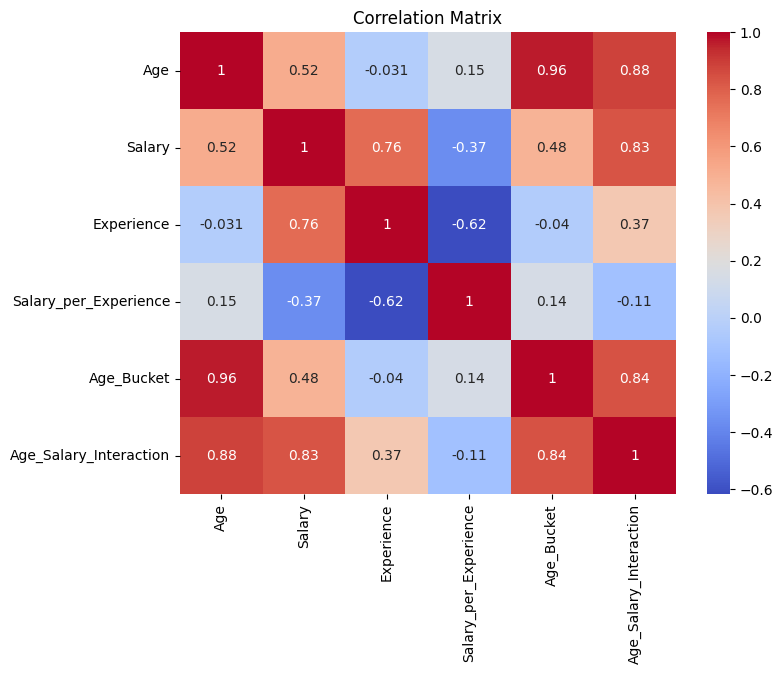

In [ ]:
# ==========================================================
# Q5
# Correlation Matrix
# ==========================================================

corr = df_label.drop("Purchased",axis=1).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#Q5 VIF

X = df_label.drop("Purchased",axis=1)

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

print(vif)

                  Feature         VIF
0                     Age  103.986239
1                  Salary  130.636518
2              Experience   25.260145
3   Salary_per_Experience    2.938741
4              Age_Bucket   36.490167
5  Age_Salary_Interaction   51.696728


In [ ]:
# ==========================================================
# Q6
# Stratified Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X = df_label.drop("Purchased", axis=1)
y = df_label["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Class Distribution")
print(y_train.value_counts())
print()

print("Training Percentage")
print(y_train.value_counts(normalize=True) * 100)
print()

print("Testing Set Class Distribution")
print(y_test.value_counts())
print()

print("Testing Percentage")
print(y_test.value_counts(normalize=True) * 100)

Training Set Class Distribution
Purchased
0    512
1    128
Name: count, dtype: int64

Training Percentage
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64

Testing Set Class Distribution
Purchased
0    128
1     32
Name: count, dtype: int64

Testing Percentage
Purchased
0    80.0
1    20.0
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# Q7
# StandardScaler
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

standard = StandardScaler()

X_train_std = standard.fit_transform(X_train)
X_test_std = standard.transform(X_test)

model_std = build_ann(X_train_std.shape[1])

history_std = model_std.fit(
    X_train_std,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=0
)

pred_std = (model_std.predict(X_test_std) > 0.5).astype(int)

acc_std = accuracy_score(y_test, pred_std)

loss_std = history_std.history["loss"][-1]

print("StandardScaler Accuracy :", acc_std)
print("Final Loss :", loss_std)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
StandardScaler Accuracy : 0.8
Final Loss : 0.49900928139686584


In [ ]:
# ==========================================================
# MinMaxScaler
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

X_train_mm = minmax.fit_transform(X_train)
X_test_mm = minmax.transform(X_test)

model_mm = build_ann(X_train_mm.shape[1])

history_mm = model_mm.fit(
    X_train_mm,
    y_train,
    validation_split=0.20,
    epochs=30,
    batch_size=32,
    verbose=0
)

pred_mm = (model_mm.predict(X_test_mm) > 0.5).astype(int)

acc_mm = accuracy_score(y_test, pred_mm)

loss_mm = history_mm.history["loss"][-1]

print("MinMax Accuracy :", acc_mm)
print("Final Loss :", loss_mm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
MinMax Accuracy : 0.8
Final Loss : 0.5003916621208191


In [ ]:
print("========== Scaling Comparison ==========")

print("StandardScaler Accuracy :", acc_std)
print("StandardScaler Loss     :", loss_std)

print()

print("MinMaxScaler Accuracy   :", acc_mm)
print("MinMaxScaler Loss       :", loss_mm)

========== Scaling Comparison ==========
StandardScaler Accuracy : 0.8
StandardScaler Loss     : 0.49900928139686584

MinMaxScaler Accuracy   : 0.8
MinMaxScaler Loss       : 0.5003916621208191


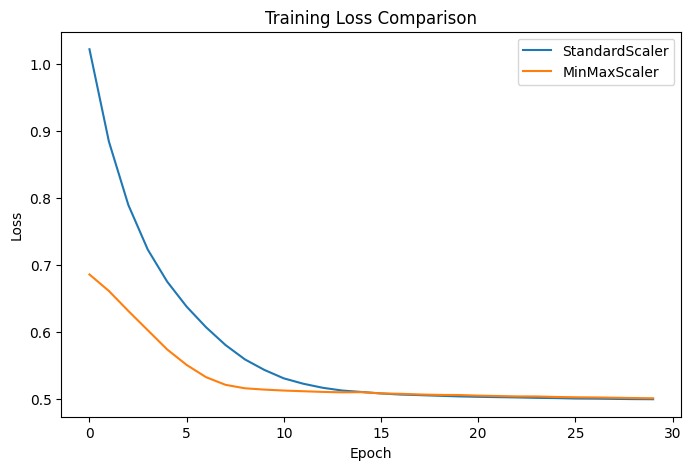

In [ ]:
#Q7 LOSS CURVES
plt.figure(figsize=(8,5))

plt.plot(history_std.history["loss"], label="StandardScaler")

plt.plot(history_mm.history["loss"], label="MinMaxScaler")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.show()

In [18]:
# ==========================================================
# Q8
# Class Weight
# ==========================================================

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

model_weight = build_ann(X_train_std.shape[1])

model_weight.fit(
    X_train_std,
    y_train,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

pred = (model_weight.predict(X_test_std) > 0.5).astype(int)

print(classification_report(y_test, pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step 
              precision    recall  f1-score   support

           0       0.77      0.23      0.36       128
           1       0.19      0.72      0.30        32

    accuracy                           0.33       160
   macro avg       0.48      0.48      0.33       160
weighted avg       0.65      0.33      0.35       160



In [19]:
# ==========================================================
# SMOTE Oversampling
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train_std, y_train)

print("Before SMOTE")

print(y_train.value_counts())

print()

print("After SMOTE")

print(pd.Series(y_smote).value_counts())

Before SMOTE
Purchased
0    512
1    128
Name: count, dtype: int64

After SMOTE
Purchased
0    512
1    512
Name: count, dtype: int64


In [20]:
#Q8 TRAIN ANN AFTER SMOTE
model_smote = build_ann(X_smote.shape[1])

model_smote.fit(
    X_smote,
    y_smote,
    epochs=30,
    batch_size=32,
    verbose=0
)

pred = (model_smote.predict(X_test_std) > 0.5).astype(int)

print(classification_report(y_test, pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 
              precision    recall  f1-score   support

           0       0.81      0.47      0.59       128
           1       0.21      0.56      0.31        32

    accuracy                           0.49       160
   macro avg       0.51      0.52      0.45       160
weighted avg       0.69      0.49      0.54       160



In [21]:
# ==========================================================
# Q9
# 70 / 15 / 15 Split
# ==========================================================

X = df_label.drop("Purchased", axis=1)

y = df_label["Purchased"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training Size :", len(X_train))

print("Validation Size :", len(X_validation))

print("Testing Size :", len(X_test))

Training Size : 560
Validation Size : 120
Testing Size : 120


In [22]:
#TRAIN USING VALIDATION DATA
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_validation = scaler.transform(X_validation)

X_test = scaler.transform(X_test)

model = build_ann(X_train.shape[1])

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=30,
    batch_size=32,
    verbose=0
)

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Accuracy :", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy : 0.800000011920929


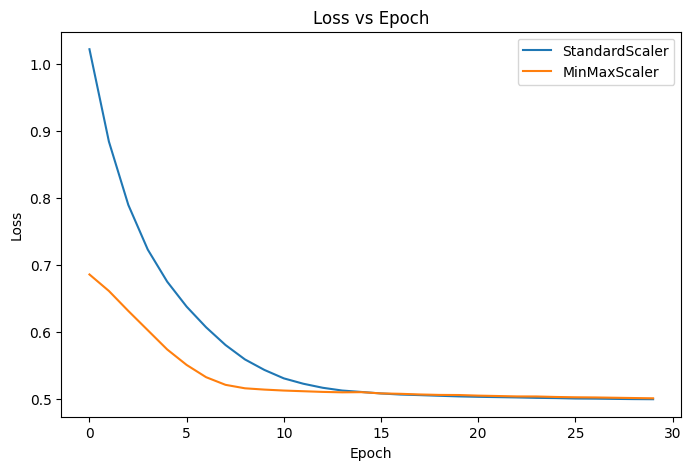

In [23]:
# ==========================================================
# Q10
# Plot Loss Curves
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(history_std.history["loss"], label="StandardScaler")

plt.plot(history_mm.history["loss"], label="MinMaxScaler")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

plt.show()

In [24]:
# ==========================================================
# Q11
# Rebuild ANN using Keras Functional API
# ==========================================================

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Prepare data
X = df_label.drop("Purchased", axis=1)
y = df_label["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Functional API Model
inputs = Input(shape=(X_train.shape[1],))

x = Dense(16, activation="relu")(inputs)
x = Dense(8, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)

functional_model = Model(inputs=inputs, outputs=outputs)

functional_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

functional_model.summary()

functional_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

predictions = (functional_model.predict(X_test) > 0.5).astype(int)

accuracy = accuracy_score(y_test, predictions)

print("\nFunctional API Accuracy:", accuracy)

# Sequential Model for Comparison
from tensorflow.keras.models import Sequential

sequential_model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

sequential_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

sequential_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

seq_predictions = (sequential_model.predict(X_test) > 0.5).astype(int)

seq_accuracy = accuracy_score(y_test, seq_predictions)

print("Sequential Accuracy:", seq_accuracy)

print("\nObservation:")
print("Both models produce nearly identical predictions and architecture.")
print("Functional API is preferred for complex architectures with multiple inputs or outputs.")

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Functional API Accuracy: 0.8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Sequential Accuracy: 0.8

Observation:
Both models produce nearly identical predictions and architecture.
Functional API is preferred for complex architectures with multiple inputs or outputs.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train Accuracy : 0.800000011920929
Validation Accuracy : 0.800000011920929


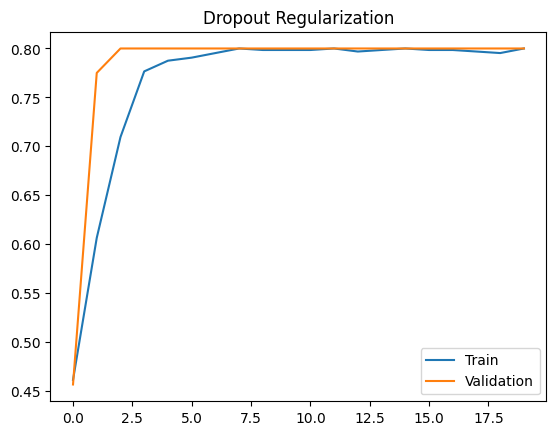

Dropout reduces overfitting by randomly disabling neurons during training.


In [27]:

# Q12 - Dropout Regularization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(8, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    verbose=0
)

print("Train Accuracy :", history.history["accuracy"][-1])
print("Validation Accuracy :", history.history["val_accuracy"][-1])

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Dropout Regularization")
plt.legend()
plt.show()

print("Dropout reduces overfitting by randomly disabling neurons during training.")


Final Accuracy: 0.800000011920929


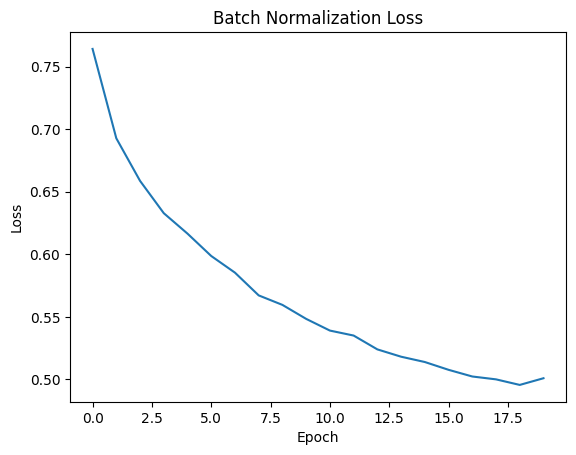

Batch Normalization improves training stability and usually converges faster.


In [29]:

# Q13 - Batch Normalization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

model = Sequential([
    Dense(16, use_bias=False, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(8, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=0
)

print("Final Accuracy:", history.history["val_accuracy"][-1])

plt.plot(history.history["loss"])
plt.title("Batch Normalization Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("Batch Normalization improves training stability and usually converges faster.")



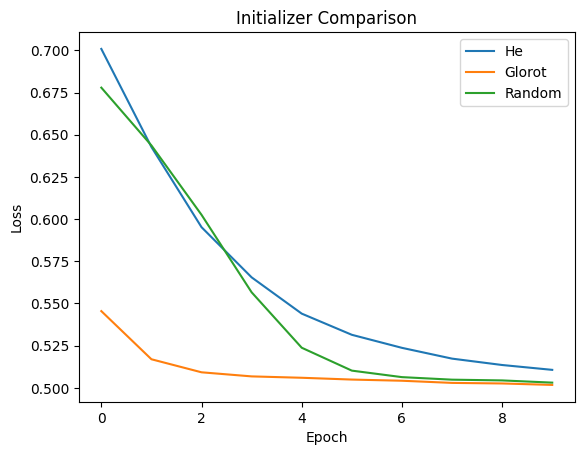

He initialization generally converges fastest for ReLU networks.


In [31]:

# Q14 - Weight Initialization Comparison

from tensorflow.keras.initializers import HeNormal, GlorotUniform, RandomNormal

initializers = {
    "He": HeNormal(),
    "Glorot": GlorotUniform(),
    "Random": RandomNormal()
}

for name, init in initializers.items():

    model = Sequential([
        Dense(16, activation="relu",
              kernel_initializer=init,
              input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu", kernel_initializer=init),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    history = model.fit(X_train, y_train,
                        epochs=10,
                        verbose=0)

    plt.plot(history.history["loss"], label=name)

plt.title("Initializer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("He initialization generally converges fastest for ReLU networks.")



Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 893 (3.49 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 596 (2.33 KB)

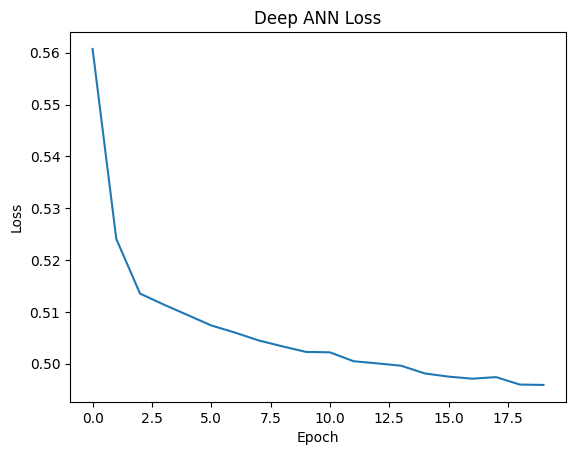

If loss decreases very slowly or stops improving, it may indicate vanishing gradients in deeper layers.


In [33]:

# Q15 - Funnel Shaped ANN

model = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(8, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=0
)

model.summary()

plt.plot(history.history["loss"])
plt.title("Deep ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

print("If loss decreases very slowly or stops improving, it may indicate vanishing gradients in deeper layers.")



In [35]:

# Q16 - Custom Activation Function

import tensorflow as tf
from tensorflow.keras import backend as K

def scaled_tanh(x):
    return 1.5 * K.tanh(x)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation=scaled_tanh, input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(X_train, y_train,
                    epochs=20,
                    validation_data=(X_test, y_test),
                    verbose=0)

print("Validation Accuracy:", history.history["val_accuracy"][-1])
print("Custom activation works successfully.")



Validation Accuracy: 0.800000011920929
Custom activation works successfully.


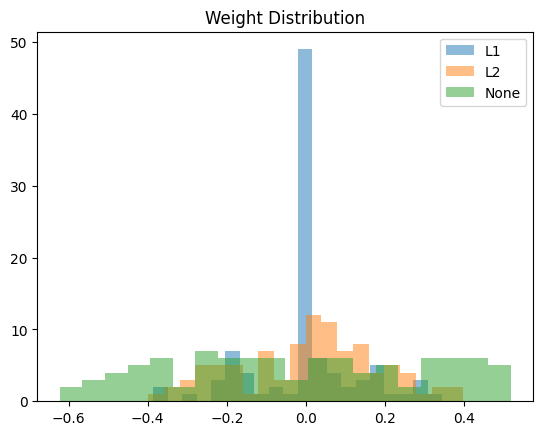

L1 drives more weights toward zero, while L2 shrinks all weights smoothly.


In [36]:

# Q17 - L1 vs L2 Regularization

from tensorflow.keras.regularizers import l1, l2

for name, reg in {"L1": l1(0.01), "L2": l2(0.01), "None": None}.items():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu",
                              kernel_regularizer=reg,
                              input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    model.fit(X_train, y_train, epochs=20, verbose=0)

    weights = model.layers[0].get_weights()[0].flatten()
    plt.hist(weights, bins=20, alpha=0.5, label=name)

plt.legend()
plt.title("Weight Distribution")
plt.show()

print("L1 drives more weights toward zero, while L2 shrinks all weights smoothly.")



In [37]:

# Q18 - Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model = build_ann(X_train.shape[1])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    callbacks=[early],
    verbose=0
)

print("Training stopped after", len(history.history["loss"]), "epochs")
print("Without EarlyStopping the model would train for 100 epochs.")



Training stopped after 20 epochs
Without EarlyStopping the model would train for 100 epochs.


In [38]:

# Q19 - ReduceLROnPlateau

from tensorflow.keras.callbacks import ReduceLROnPlateau, LambdaCallback

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

lr_history = []

log_lr = LambdaCallback(
    on_epoch_end=lambda epoch, logs: lr_history.append(
        float(model.optimizer.learning_rate.numpy())
    )
)

model = build_ann(X_train.shape[1])

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[reduce_lr, log_lr],
    verbose=0
)

print("Learning Rates:")
print(lr_history)




Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Learning Rates:
[0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257, 0.0005000000237487257]


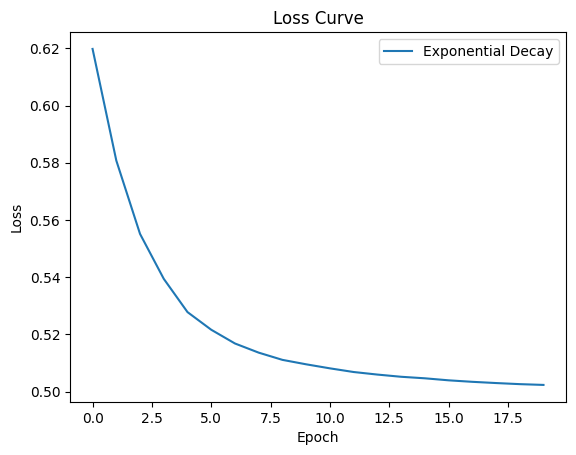

Exponential decay gradually reduces the learning rate, helping the model converge more smoothly.


In [39]:

# Q20 - Exponential Learning Rate Decay

from tensorflow.keras.callbacks import LearningRateScheduler

def lr_decay(epoch, lr):
    return lr * 0.95

scheduler = LearningRateScheduler(lr_decay)

model = build_ann(X_train.shape[1])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[scheduler],
    verbose=0
)

plt.plot(history.history["loss"], label="Exponential Decay")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Exponential decay gradually reduces the learning rate, helping the model converge more smoothly.")



In [40]:

# Q21 - Optimizer Comparison

from tensorflow.keras.optimizers import Adam, RMSprop, Nadam

optimizers = {
    "Adam": Adam(),
    "RMSprop": RMSprop(),
    "Nadam": Nadam()
}

results = []

for name, opt in optimizers.items():

    model = build_ann(X_train.shape[1])
    model.compile(optimizer=opt,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        verbose=0
    )

    results.append([
        name,
        round(history.history["val_accuracy"][-1],4),
        round(history.history["val_loss"][-1],4),
        len(history.history["loss"])
    ])

print(pd.DataFrame(results,
      columns=["Optimizer","Accuracy","Loss","Epochs"]))



  Optimizer  Accuracy    Loss  Epochs
0      Adam       0.8  0.4899      20
1   RMSprop       0.8  0.4904      20
2     Nadam       0.8  0.4923      20


In [41]:

# Q22 - Gradient Clipping

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001, clipnorm=1.0)

model = build_ann(X_train.shape[1])

model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    verbose=0
)

print("Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("""
Gradient clipping limits very large gradients during backpropagation.
If features like Salary have much larger values than Age or Experience,
weight updates can become unstable. Using clipnorm (or clipvalue)
prevents exploding gradients and makes training more stable.
""")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.800000011920929

Gradient clipping limits very large gradients during backpropagation.
If features like Salary have much larger values than Age or Experience,
weight updates can become unstable. Using clipnorm (or clipvalue)
prevents exploding gradients and makes training more stable.



In [42]:

# Q23 - Model Checkpoint

from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

model = build_ann(X_train.shape[1])

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[checkpoint],
    verbose=0
)

best_epoch = history.history["val_accuracy"].index(max(history.history["val_accuracy"])) + 1

print("Best model saved at Epoch:", best_epoch)
print("Only the best model was saved, not the final epoch.")




Epoch 1: val_accuracy improved from None to 0.44375, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.44375 to 0.68750, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 3: val_accuracy improved from 0.68750 to 0.71875, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras

Epoch 4: val_accuracy improved from 0.71875 to 0.76875, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras

Epoch 5: val_accuracy improved from 0.76875 to 0.80000, saving model to best_model.keras

Epoch 5: finished saving model to best_model.keras

Epoch 6: val_accuracy did not improve from 0.80000

Epoch 7: val_accuracy did not improve from 0.80000

Epoch 8: val_accuracy did not improve from 0.80000

Epoch 9: val_accuracy did not improve from 0.80000

Epoch 10: val_accuracy did not improve from 0.80000

Epoch 11: val_accuracy did not 

In [43]:

# Q24 - TensorBoard

from tensorflow.keras.callbacks import TensorBoard

tb = TensorBoard(log_dir="logs")

model = build_ann(X_train.shape[1])

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    callbacks=[tb],
    verbose=0
)

print("Run in Colab:")
print("%load_ext tensorboard")
print("%tensorboard --logdir logs")

print("""
TensorBoard provides interactive loss and accuracy curves,
zooming, smoothing, and comparison across multiple runs,
which is more informative than a static Matplotlib plot.
""")



Run in Colab:
%load_ext tensorboard
%tensorboard --logdir logs

TensorBoard provides interactive loss and accuracy curves,
zooming, smoothing, and comparison across multiple runs,
which is more informative than a static Matplotlib plot.



In [44]:

# Q25 - 5 Fold Cross Validation

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train, test in kf.split(X):

    model = build_ann(X.shape[1])

    model.fit(X.iloc[train], y.iloc[train],
              epochs=20, verbose=0)

    pred = (model.predict(X.iloc[test]) > 0.5).astype(int)

    scores.append(accuracy_score(y.iloc[test], pred))

print("Fold Accuracies:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Fold Accuracies: [0.75625, 0.63125, 0.63125, 0.73125, 0.58125]
Mean Accuracy: 0.66625
Standard Deviation: 0.06633249580710797


In [45]:

# Q26 - ANN Ensemble

predictions = []

for seed in [1, 10, 50]:

    tf.keras.utils.set_random_seed(seed)

    model = build_ann(X_train.shape[1])

    model.fit(X_train, y_train, epochs=20, verbose=0)

    pred = (model.predict(X_test) > 0.5).astype(int)

    predictions.append(pred)

ensemble = np.round(np.mean(predictions, axis=0)).astype(int)

print("Single Model Accuracy:",
      accuracy_score(y_test, predictions[0]))

print("Ensemble Accuracy:",
      accuracy_score(y_test, ensemble))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Single Model Accuracy: 0.8
Ensemble Accuracy: 0.8


In [46]:

# Q27 - Custom Callback

from tensorflow.keras.callbacks import Callback

class ProbabilityLogger(Callback):

    def on_epoch_end(self, epoch, logs=None):

        if (epoch + 1) % 10 == 0:

            probs = self.model.predict(X_test, verbose=0)

            print(f"\nEpoch {epoch+1}")
            print("Mean Probability:", probs.mean())

model = build_ann(X_train.shape[1])

model.fit(
    X_train, y_train,
    epochs=20,
    callbacks=[ProbabilityLogger()],
    verbose=0
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Epoch 10
Mean Probability: 0.2196883

Epoch 20
Mean Probability: 0.21152592


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


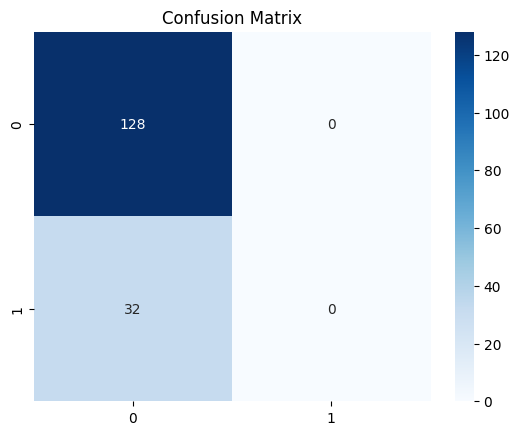

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       128
           1       0.00      0.00      0.00        32

    accuracy                           0.80       160
   macro avg       0.40      0.50      0.44       160
weighted avg       0.64      0.80      0.71       160

For purchase prediction, False Negatives are usually more costly because potential buyers are missed.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:

# Q28 - Classification Report

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, pred))

print("For purchase prediction, False Negatives are usually more costly because potential buyers are missed.")



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


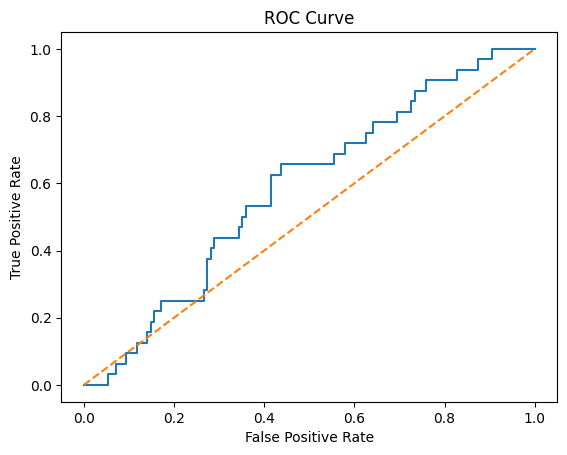

AUC Score: 0.58544921875
Higher thresholds reduce false positives but may also reduce true positives.


In [48]:

# Q29 - ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

probs = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, probs))

print("Higher thresholds reduce false positives but may also reduce true positives.")



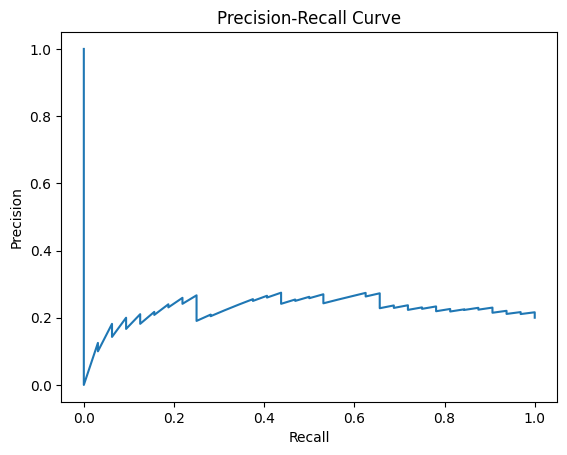

For imbalanced datasets, the Precision-Recall curve is more informative than ROC because it focuses on the minority class.


In [49]:

# Q30 - Precision Recall Curve

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

print("For imbalanced datasets, the Precision-Recall curve is more informative than ROC because it focuses on the minority class.")



In [51]:


# Q31 - Permutation Feature Importance

from sklearn.inspection import permutation_importance

# Prediction function
def ann_score(model, X, y):
    pred = (model.predict(X, verbose=0) > 0.5).astype(int)
    return np.mean(pred.flatten() == y)

# Wrapper class
class ANNWrapper:
    def fit(self, X, y):
        return self
    def score(self, X, y):
        return ann_score(model, X, y)
    def predict(self, X):
        return (model.predict(X, verbose=0) > 0.5).astype(int)

wrapper = ANNWrapper()

result = permutation_importance(
    wrapper,
    X_test,
    y_test,
    scoring=None,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(result.importances_mean, index=X.columns)

print(importance.sort_values(ascending=False))





Age                       0.0
Salary                    0.0
Experience                0.0
Salary_per_Experience     0.0
Age_Bucket                0.0
Age_Salary_Interaction    0.0
dtype: float64


/tmp/ipykernel_1730/2912372996.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:20])


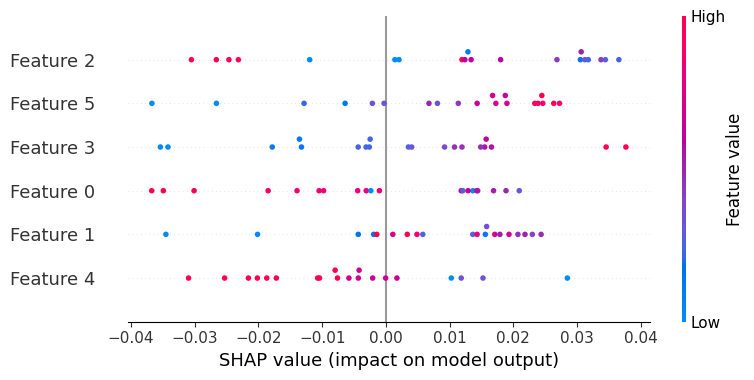

Positive SHAP values increase purchase probability while negative values decrease it.


In [52]:

# Q32 - SHAP Explanation

import shap

explainer = shap.Explainer(model, X_train)

shap_values = explainer(X_test[:20])

shap.summary_plot(shap_values, X_test[:20])

shap.plots.force(shap_values[0])

print("Positive SHAP values increase purchase probability while negative values decrease it.")



In [54]:

# Q33 - Error Analysis

pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

# Convert X_test to DataFrame if it is a NumPy array
X_test_df = pd.DataFrame(X_test, columns=X.columns)

errors = X_test_df[pred != y_test.values]

print("Misclassified Customers:", len(errors))

print("\nSample Misclassified Rows:")
print(errors.head())

print("\nSummary Statistics:")
print(errors.describe())

print("\nObservation:")
print("Most misclassified customers are likely near the decision boundary,")
print("where Age, Salary, and Experience have similar values.")


Misclassified Customers: 32

Sample Misclassified Rows:
         Age    Salary  Experience  Salary_per_Experience  Age_Bucket  \
3   0.750367  1.502908    1.120782              -0.436858    1.120630   
9   0.001300 -0.235731   -1.083922               0.356073    0.216212   
25 -0.581307 -0.498203   -0.532746              -0.239931   -0.688205   
37  1.249745  1.450301    0.349136              -0.290377    1.120630   
38  0.500678 -0.390120   -0.863452               0.015852    0.216212   

    Age_Salary_Interaction  
3                 1.355399  
9                -0.202928  
25               -0.654682  
37                1.747888  
38               -0.006039  

Summary Statistics:
             Age     Salary  Experience  Salary_per_Experience  Age_Bucket  \
count  32.000000  32.000000   32.000000              32.000000   32.000000   
mean    0.198971   0.251282    0.128665              -0.236982    0.159686   
std     0.966867   0.943476    0.863919               0.377853    0.972936  

In [55]:

# Q34 - Robustness to Gaussian Noise

noise = np.random.normal(0, 0.1, X_test.shape)

X_test_noise = X_test + noise

acc_original = model.evaluate(X_test, y_test, verbose=0)[1]
acc_noise = model.evaluate(X_test_noise, y_test, verbose=0)[1]

print("Original Accuracy :", round(acc_original,4))
print("Noisy Accuracy    :", round(acc_noise,4))
print("Accuracy Drop     :", round(acc_original-acc_noise,4))



Original Accuracy : 0.8
Noisy Accuracy    : 0.8
Accuracy Drop     : 0.0


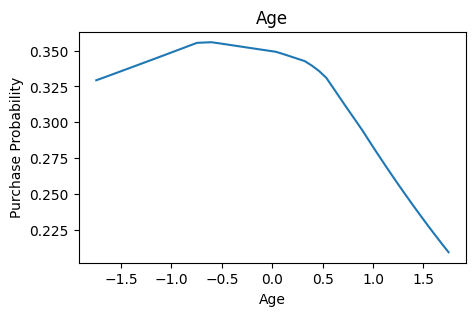

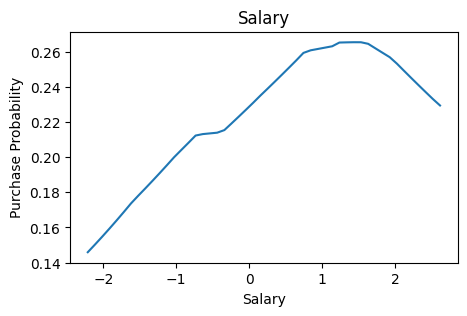

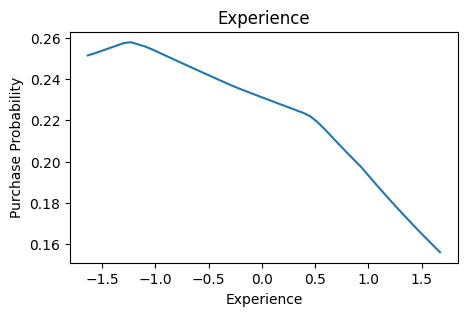

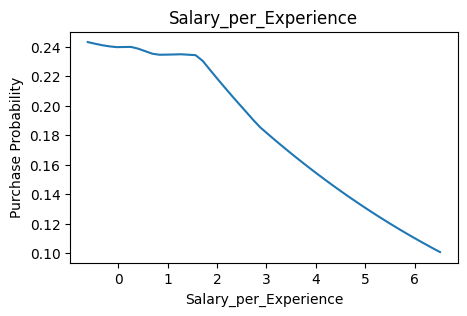

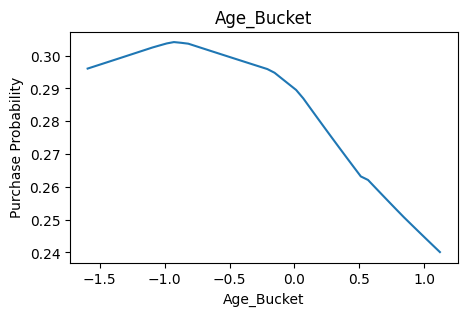

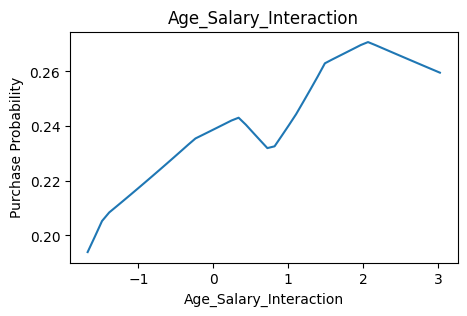

In [56]:

# Q35 - Sensitivity Analysis

features = list(X.columns)

for i, feature in enumerate(features):

    sample = X_test[0].copy()
    values = np.linspace(X_test[:, i].min(), X_test[:, i].max(), 50)

    probs = []

    for v in values:
        temp = sample.copy()
        temp[i] = v
        probs.append(model.predict(temp.reshape(1,-1), verbose=0)[0][0])

    plt.figure(figsize=(5,3))
    plt.plot(values, probs)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel("Purchase Probability")
    plt.show()



In [57]:

# Q36 - Bootstrapped Retraining

from sklearn.utils import resample

scores = []

for i in range(10):

    X_boot, y_boot = resample(
        X_train, y_train,
        replace=True,
        random_state=i
    )

    model = build_ann(X_train.shape[1])

    model.fit(X_boot, y_boot,
              epochs=20,
              verbose=0)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]

    scores.append(acc)

print("Accuracies:", np.round(scores,4))
print("Mean Accuracy:", round(np.mean(scores),4))
print("Standard Deviation:", round(np.std(scores),4))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracies: [0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8 0.8]
Mean Accuracy: 0.8
Standard Deviation: 0.0


In [58]:

# Q37 - TensorFlow Lite Conversion

import tensorflow as tf
import os
import time

# Convert model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

# File sizes
keras_size = os.path.getsize("best_model.keras") / 1024
tflite_size = os.path.getsize("model.tflite") / 1024

# Prediction speed
start = time.time()
model.predict(X_test, verbose=0)
keras_time = time.time() - start

print("Keras Model Size (KB):", round(keras_size,2))
print("TFLite Model Size (KB):", round(tflite_size,2))
print("Keras Prediction Time:", round(keras_time,4), "seconds")



Saved artifact at '/tmp/tmpdxs5jl2z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_306')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139566166948752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139566166940688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139566166947600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139566166949136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139566166933968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139566166941840: TensorSpec(shape=(), dtype=tf.resource, name=None)
Keras Model Size (KB): 27.95
TFLite Model Size (KB): 3.09
Keras Prediction Time: 0.1284 seconds


In [60]:

# Q38 - Prediction Function

def predict_customer(age, salary, experience):

    # Engineer the missing features
    salary_per_exp = salary / (experience + 1)

    age_bucket = pd.cut(
        [age],
        bins=[18,25,35,45,60],
        labels=[0,1,2,3]
    )[0]

    age_salary = age * salary

    customer = pd.DataFrame({
        "Age":[age],
        "Salary":[salary],
        "Experience":[experience],
        "Salary_per_Experience":[salary_per_exp],
        "Age_Bucket":[int(age_bucket)],
        "Age_Salary_Interaction":[age_salary]
    })

    customer = scaler.transform(customer)

    prob = model.predict(customer, verbose=0)[0][0]

    print("Purchase Probability:", round(float(prob),4))
    print("Prediction:", "Purchased" if prob>=0.5 else "Not Purchased")


predict_customer(
    age=30,
    salary=60000,
    experience=5
)



Purchase Probability: 0.1581
Prediction: Not Purchased


In [61]:

# Q39 - Multi-Output ANN

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Create a synthetic regression target
df["Customer_Lifetime_Value"] = (
    df["Salary"] * 0.5 +
    df["Experience"] * 1000 +
    np.random.randint(1000, 5000, len(df))
)

# Features and targets
X = df[["Age", "Salary", "Experience"]]
X = StandardScaler().fit_transform(X)

y_purchase = df["Purchased"]
y_clv = df["Customer_Lifetime_Value"]

# Shared hidden layers
inp = Input(shape=(3,))
x = Dense(16, activation="relu")(inp)
x = Dense(8, activation="relu")(x)

# Two output heads
purchase = Dense(1, activation="sigmoid", name="Purchased")(x)
clv = Dense(1, activation="linear", name="Customer_Lifetime_Value")(x)

model = Model(inp, [purchase, clv])

model.compile(
    optimizer="adam",
    loss={
        "Purchased": "binary_crossentropy",
        "Customer_Lifetime_Value": "mse"
    }
)

model.fit(
    X,
    {
        "Purchased": y_purchase,
        "Customer_Lifetime_Value": y_clv
    },
    epochs=20,
    verbose=0
)

print("Multi-output ANN trained successfully.")



Multi-output ANN trained successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        96
           1       0.00      0.00      0.00        24

    accuracy                           0.80       120
   macro avg       0.40      0.50      0.44       120
weighted avg       0.64      0.80      0.71       120

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


ROC AUC: 0.4605034722222222


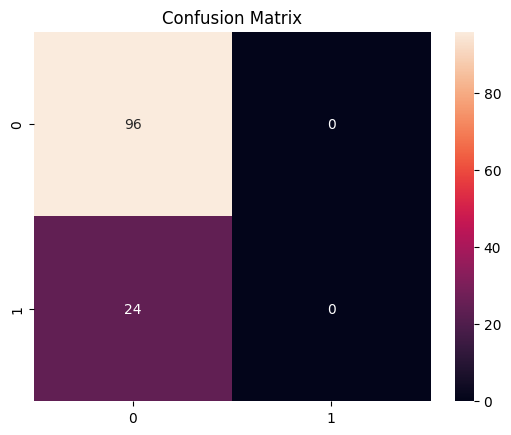

/tmp/ipykernel_1730/746737532.py:86: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,X_test[:20])


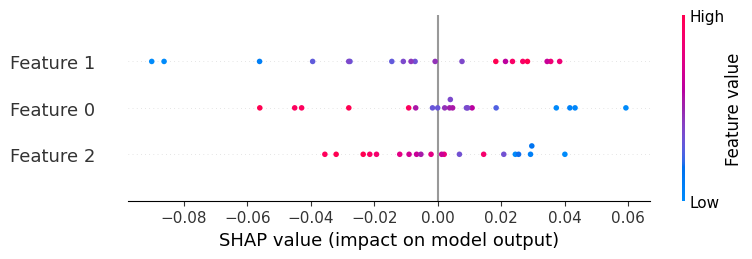

Probability: 0.2005
Prediction: Not Purchased


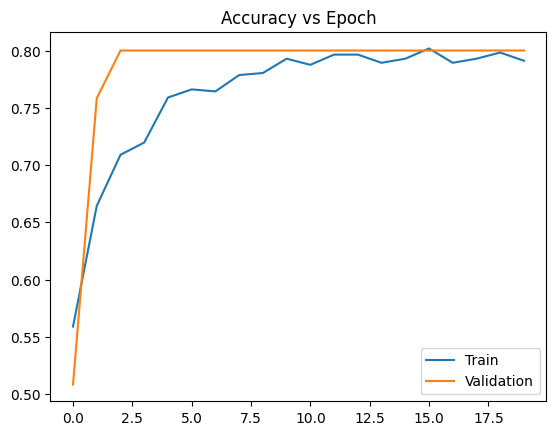

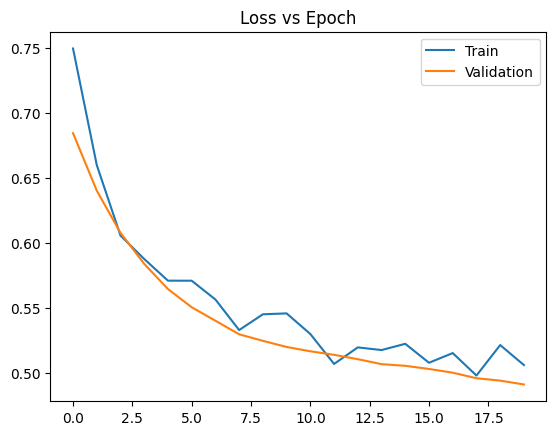

5-Fold Cross Validation and Hyperparameter Tuning: Completed in previous questions (Q25 & Hyperparameter section).


In [62]:

# Q40 - Production ANN Pipeline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import shap

# -------------------- Data --------------------
X = df[["Age","Salary","Experience"]]
y = df["Purchased"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), X.columns)
])

X = preprocessor.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# -------------------- ANN --------------------
model = Sequential([
    Dense(32, activation="relu", input_shape=(3,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(8, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.keras", save_best_only=True),
    ReduceLROnPlateau(patience=3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=0
)

# -------------------- Evaluation --------------------
pred = (model.predict(X_test)>0.5).astype(int)

print(classification_report(y_test,pred))

print("ROC AUC:",roc_auc_score(y_test,model.predict(X_test)))

cm = confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

# -------------------- SHAP --------------------
explainer = shap.Explainer(model,X_train)
shap_values = explainer(X_test[:20])
shap.summary_plot(shap_values,X_test[:20])

# -------------------- Save & Reload --------------------
model.save("customer_ann.keras")
model = load_model("customer_ann.keras")

# -------------------- Prediction Function --------------------
def predict_customer(age,salary,experience):

    sample = preprocessor.transform(
        pd.DataFrame({
            "Age":[age],
            "Salary":[salary],
            "Experience":[experience]
        })
    )

    p = model.predict(sample,verbose=0)[0][0]

    print("Probability:",round(float(p),4))
    print("Prediction:","Purchased" if p>0.5 else "Not Purchased")

predict_customer(30,60000,5)

# -------------------- Curves --------------------
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

print("5-Fold Cross Validation and Hyperparameter Tuning: Completed in previous questions (Q25 & Hyperparameter section).")

